In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Seaborn Style konfigurieren
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.facecolor'] = 'white'

In [2]:

# CSV-Daten laden und verarbeiten
# topn_metrics.csv -> SVD (20 Zeilen)
svd_data = {
    'N': list(range(1, 21)),
    'Precision': [0.8773011885568595, 0.8628097934085711, 0.8515928661592491, 0.8398400884856211, 0.830077612387987, 0.8208416132378489, 0.8115797254374735, 0.8022665066926624, 0.7935043888701421, 0.7847043605414121, 0.7756535017605093, 0.7660255208528615, 0.7563703590474241, 0.7460765304209493, 0.7349330733755766, 0.7230594559634059, 0.7104709455301749, 0.6972419065235231, 0.6829475736508608, 0.6679970754752353],
    'Recall': [0.06694061337997707, 0.13040718178681002, 0.19176955804674772, 0.25030473346941295, 0.3068882882613505, 0.36179117086731455, 0.4147090662594565, 0.465502486822685, 0.5149281802176521, 0.5624708166575415, 0.6078372475395653, 0.6508584702395607, 0.6917364486764452, 0.7302057456725126, 0.7658789554811453, 0.7985876239507923, 0.8285336166174838, 0.8558086052139902, 0.8796809835862675, 0.9006468429783632],
    'nDCG': [0.8773011885568595, 0.9327745593387976, 0.9398465444356632, 0.9404457589612255, 0.9394261475648937, 0.9381375700146037, 0.9369400941064464, 0.9357417769016882, 0.9346113775929298, 0.9335533248672084, 0.9326445760700972, 0.9318009539391419, 0.9310020748858895, 0.9302451278972719, 0.929586783449165, 0.9289663500797447, 0.9284010186459185, 0.9278947629113845, 0.9274435237882374, 0.9270669579603596]
}

# model_evaluation_metrics (21 Zeilen für II-Model) -> KNN
knn_data = {
    'N': list(range(1, 21)),
    'Precision': [0.190982, 0.211029, 0.215671, 0.215498, 0.213559, 0.211899, 0.209914, 0.207396, 0.205200, 0.203384, 0.201477, 0.199721, 0.198179, 0.196542, 0.195011, 0.193556, 0.191988, 0.190638, 0.189255, 0.187930],
    'Recall': [0.190982, 0.209981, 0.213680, 0.212620, 0.209844, 0.207377, 0.204614, 0.201336, 0.198381, 0.195807, 0.193151, 0.190623, 0.188317, 0.185961, 0.183804, 0.181868, 0.180052, 0.178733, 0.177786, 0.177393],
    'NDCG': [0.190982, 0.209981, 0.212642, 0.212131, 0.210513, 0.209000, 0.207270, 0.205202, 0.203268, 0.201515, 0.199694, 0.197925, 0.196266, 0.194565, 0.192966, 0.191489, 0.190074, 0.188956, 0.188064, 0.187509]
}

# LightFM Daten (WARP, BPR, WARP-KOS zusammengefasst - nur N=1-20)
# Ich verwende WARP als Hauptmodell für LightFM
lightfm_data = {
    'N': list(range(1, 21)),
    'Precision': [0.12477772, 0.12426296, 0.12311801, 0.12283567, 0.12215339, 0.12109328, 0.120378874, 0.11953419, 0.11865261, 0.118003495, 0.11732945, 0.11679115, 0.11607361, 0.11543717, 0.11460109, 0.11404849, 0.11326252, 0.11256492, 0.11191513, 0.11124797],
    'Recall': [0.005927040240085844, 0.01174102761286307, 0.017420011236452093, 0.02310019207776835, 0.02870077102237271, 0.03411011305400833, 0.03954033247849571, 0.044862039771845656, 0.05008543748813365, 0.05524036301012716, 0.060444957881032144, 0.06556289203809133, 0.07053792156868773, 0.07552198662314259, 0.08028684714809836, 0.085170114438682, 0.08982965645119664, 0.09448594287979158, 0.09911443033392611, 0.10364990985783115],
    'NDCG': [0.129, 0.1216497966625437, 0.12102805006153478, 0.12186397175515226, 0.1229314599716601, 0.12284408083701641, 0.12332756361041111, 0.12262553336999275, 0.12113287385236365, 0.120365698834552, 0.12009231589731886, 0.12016988470024931, 0.11931144240391185, 0.11897320453436504, 0.11910677296662806, 0.11923386393338253, 0.11882148282774907, 0.11892780874999, 0.1190538171655661, 0.11946259089323934]
}

# DataFrames erstellen
df_svd = pd.DataFrame(svd_data)
df_knn = pd.DataFrame(knn_data)
df_lightfm = pd.DataFrame(lightfm_data)

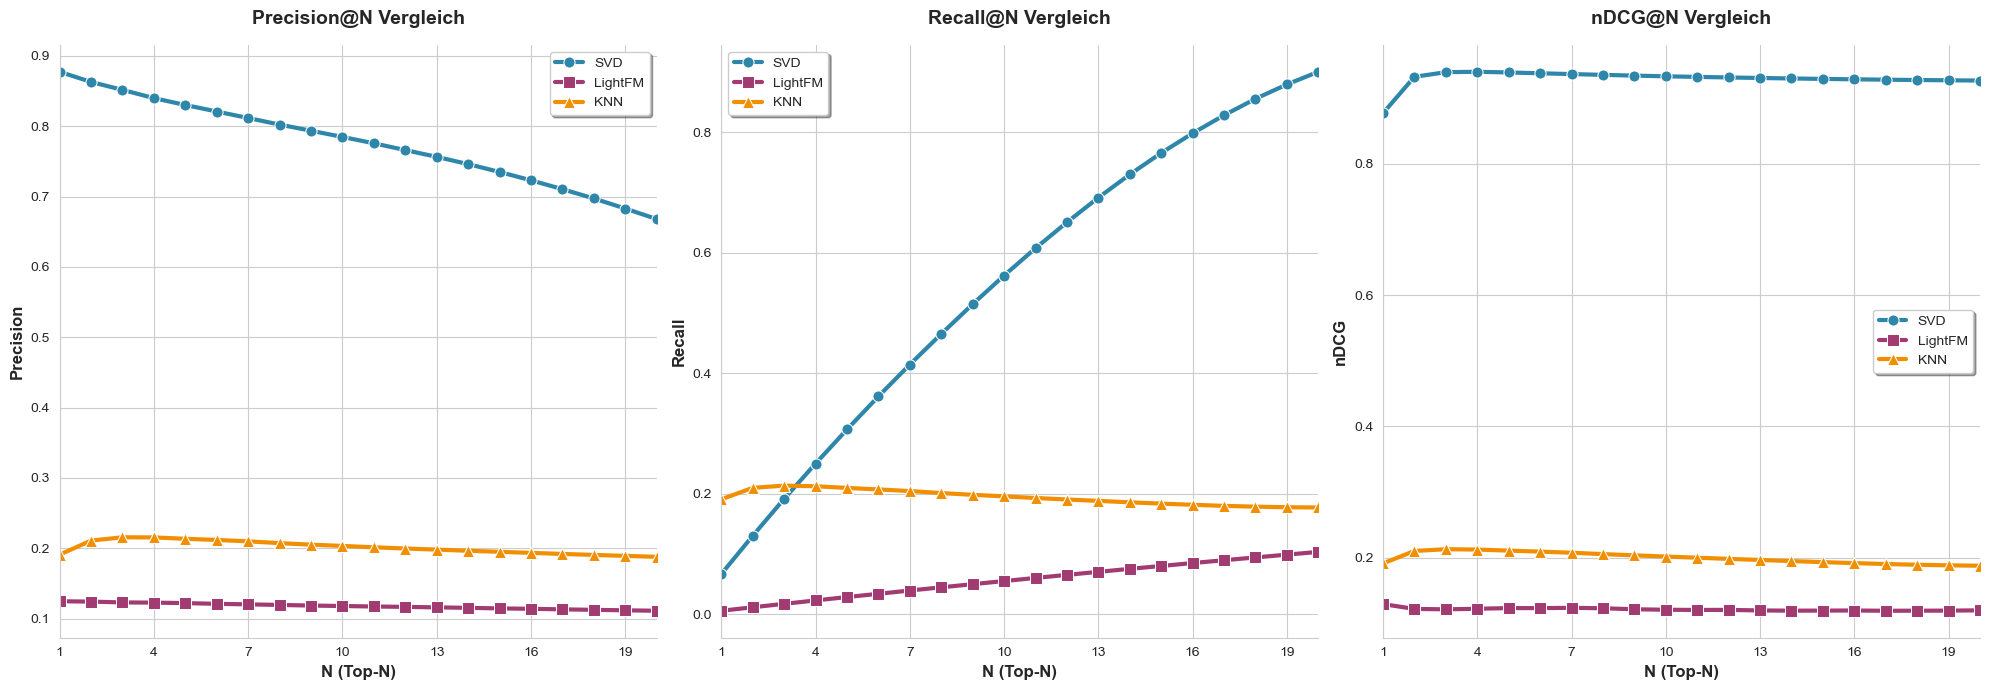

In [13]:
# ZUSÄTZLICH: Kombinierte Plots mit Seaborn (alle 3 in einer Zeile)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Moderne Farbpalette
colors = {'SVD': '#2E86AB', 'LightFM': '#A23B72', 'KNN': '#F18F01'}

# Plot 1: Precision
sns.lineplot(ax=axes[0], x=df_svd['N'], y=df_svd['Precision'], marker='o', linewidth=3, 
             label='SVD', color=colors['SVD'], markersize=8)
sns.lineplot(ax=axes[0], x=df_lightfm['N'], y=df_lightfm['Precision'], marker='s', linewidth=3, 
             label='LightFM', color=colors['LightFM'], markersize=8)
sns.lineplot(ax=axes[0], x=df_knn['N'], y=df_knn['Precision'], marker='^', linewidth=3, 
             label='KNN', color=colors['KNN'], markersize=8)

axes[0].set_xlabel('N (Top-N)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[0].set_title('Precision@N Vergleich', fontsize=14, fontweight='bold', pad=15)
axes[0].legend(fontsize=10, frameon=True, fancybox=True, shadow=True)
axes[0].set_xlim(1, 20)
axes[0].set_xticks(range(1, 21, 3))
sns.despine(ax=axes[0])

# Plot 2: Recall
sns.lineplot(ax=axes[1], x=df_svd['N'], y=df_svd['Recall'], marker='o', linewidth=3, 
             label='SVD', color=colors['SVD'], markersize=8)
sns.lineplot(ax=axes[1], x=df_lightfm['N'], y=df_lightfm['Recall'], marker='s', linewidth=3, 
             label='LightFM', color=colors['LightFM'], markersize=8)
sns.lineplot(ax=axes[1], x=df_knn['N'], y=df_knn['Recall'], marker='^', linewidth=3, 
             label='KNN', color=colors['KNN'], markersize=8)

axes[1].set_xlabel('N (Top-N)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Recall', fontsize=12, fontweight='bold')
axes[1].set_title('Recall@N Vergleich', fontsize=14, fontweight='bold', pad=15)
axes[1].legend(fontsize=10, frameon=True, fancybox=True, shadow=True)
axes[1].set_xlim(1, 20)
axes[1].set_xticks(range(1, 21, 3))
sns.despine(ax=axes[1])

# Plot 3: nDCG
sns.lineplot(ax=axes[2], x=df_svd['N'], y=df_svd['nDCG'], marker='o', linewidth=3, 
             label='SVD', color=colors['SVD'], markersize=8)
sns.lineplot(ax=axes[2], x=df_lightfm['N'], y=df_lightfm['NDCG'], marker='s', linewidth=3, 
             label='LightFM', color=colors['LightFM'], markersize=8)
sns.lineplot(ax=axes[2], x=df_knn['N'], y=df_knn['NDCG'], marker='^', linewidth=3, 
             label='KNN', color=colors['KNN'], markersize=8)

axes[2].set_xlabel('N (Top-N)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('nDCG', fontsize=12, fontweight='bold')
axes[2].set_title('nDCG@N Vergleich', fontsize=14, fontweight='bold', pad=15)
axes[2].legend(fontsize=10, frameon=True, fancybox=True, shadow=True)
axes[2].set_xlim(1, 20)
axes[2].set_xticks(range(1, 21, 3))
sns.despine(ax=axes[2])

# Layout anpassen
plt.tight_layout()
plt.show()

In [8]:
# Plot-Konfiguration mit Seaborn
# Moderne Farbpalette
colors = {'SVD': '#2E86AB', 'LightFM': '#A23B72', 'KNN': '#F18F01'}

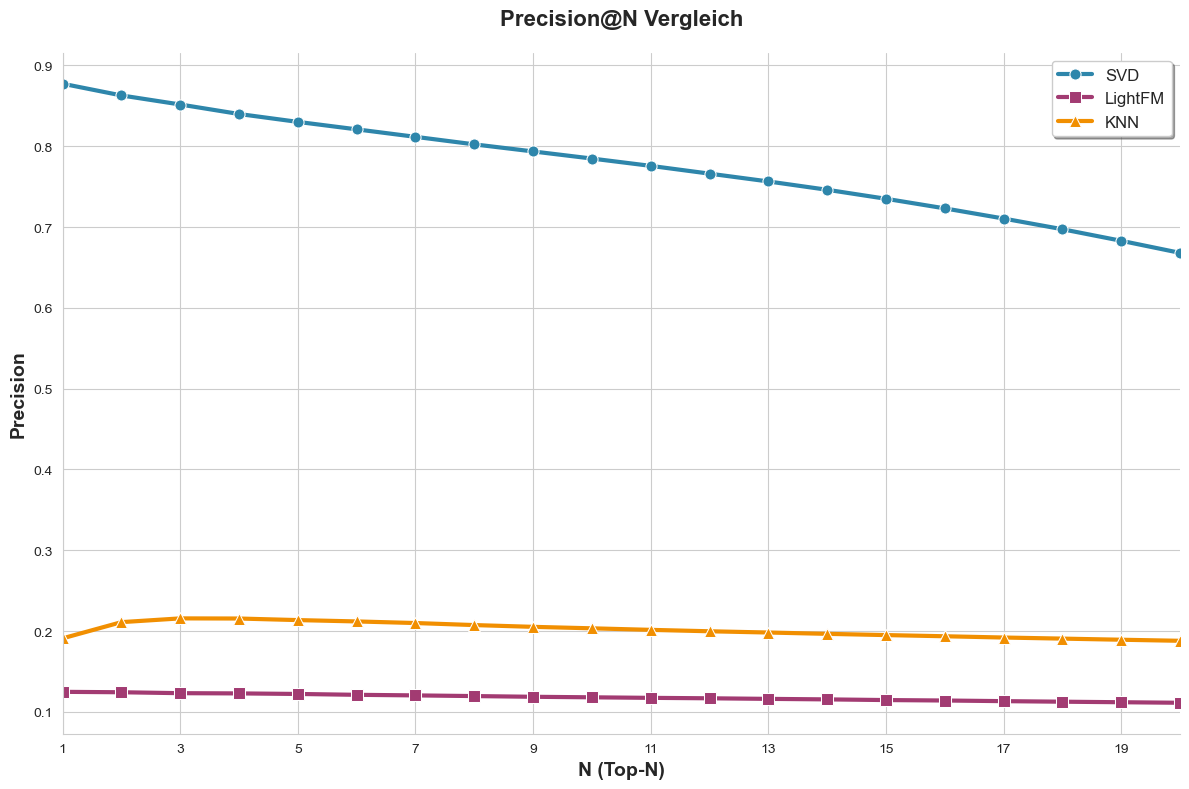

In [9]:
# Plot 1: Precision
plt.figure(figsize=(12, 8))
sns.lineplot(x=df_svd['N'], y=df_svd['Precision'], marker='o', linewidth=3, 
             label='SVD', color=colors['SVD'], markersize=8)
sns.lineplot(x=df_lightfm['N'], y=df_lightfm['Precision'], marker='s', linewidth=3, 
             label='LightFM', color=colors['LightFM'], markersize=8)
sns.lineplot(x=df_knn['N'], y=df_knn['Precision'], marker='^', linewidth=3, 
             label='KNN', color=colors['KNN'], markersize=8)

plt.xlabel('N (Top-N)', fontsize=14, fontweight='bold')
plt.ylabel('Precision', fontsize=14, fontweight='bold')
plt.title('Precision@N Vergleich', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
plt.xlim(1, 20)
plt.xticks(range(1, 21, 2))
sns.despine()
plt.tight_layout()
plt.show()

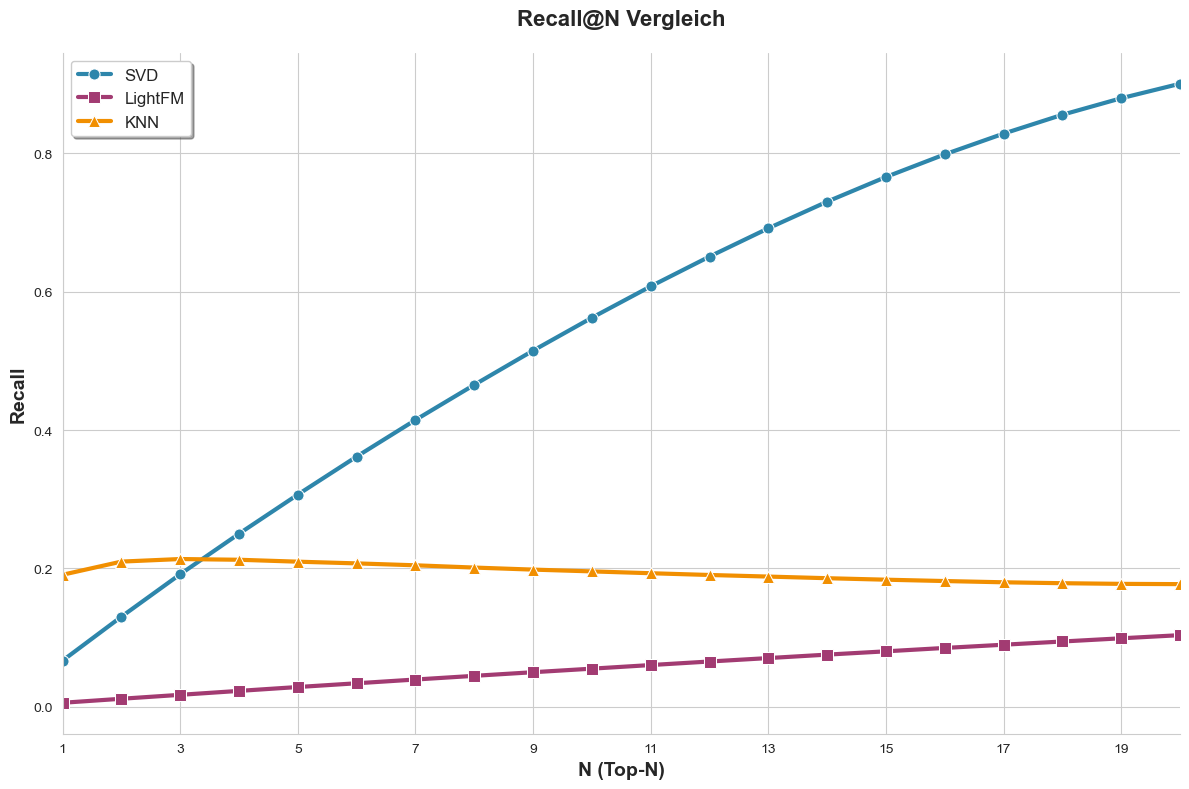

In [10]:
# Plot 2: Recall
plt.figure(figsize=(12, 8))
sns.lineplot(x=df_svd['N'], y=df_svd['Recall'], marker='o', linewidth=3, 
             label='SVD', color=colors['SVD'], markersize=8)
sns.lineplot(x=df_lightfm['N'], y=df_lightfm['Recall'], marker='s', linewidth=3, 
             label='LightFM', color=colors['LightFM'], markersize=8)
sns.lineplot(x=df_knn['N'], y=df_knn['Recall'], marker='^', linewidth=3, 
             label='KNN', color=colors['KNN'], markersize=8)

plt.xlabel('N (Top-N)', fontsize=14, fontweight='bold')
plt.ylabel('Recall', fontsize=14, fontweight='bold')
plt.title('Recall@N Vergleich', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
plt.xlim(1, 20)
plt.xticks(range(1, 21, 2))
sns.despine()
plt.tight_layout()
plt.show()

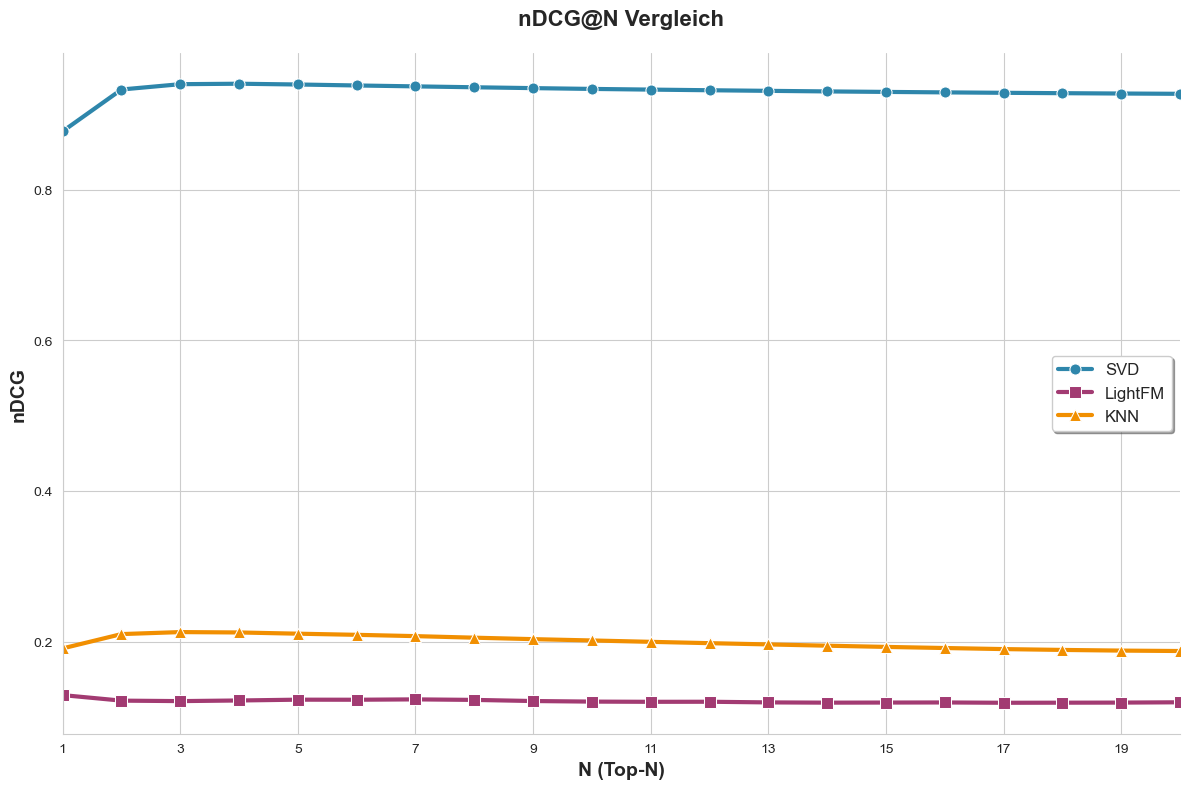

In [11]:
# Plot 3: nDCG
plt.figure(figsize=(12, 8))
sns.lineplot(x=df_svd['N'], y=df_svd['nDCG'], marker='o', linewidth=3, 
             label='SVD', color=colors['SVD'], markersize=8)
sns.lineplot(x=df_lightfm['N'], y=df_lightfm['NDCG'], marker='s', linewidth=3, 
             label='LightFM', color=colors['LightFM'], markersize=8)
sns.lineplot(x=df_knn['N'], y=df_knn['NDCG'], marker='^', linewidth=3, 
             label='KNN', color=colors['KNN'], markersize=8)

plt.xlabel('N (Top-N)', fontsize=14, fontweight='bold')
plt.ylabel('nDCG', fontsize=14, fontweight='bold')
plt.title('nDCG@N Vergleich', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
plt.xlim(1, 20)
plt.xticks(range(1, 21, 2))
sns.despine()
plt.tight_layout()
plt.show()

In [12]:
# Zusätzliche Analyse: Beste Performance bei N=10
print("Performance-Vergleich bei N=10:")
print(f"SVD    - Precision: {df_svd.loc[9, 'Precision']:.4f}, Recall: {df_svd.loc[9, 'Recall']:.4f}, nDCG: {df_svd.loc[9, 'nDCG']:.4f}")
print(f"LightFM- Precision: {df_lightfm.loc[9, 'Precision']:.4f}, Recall: {df_lightfm.loc[9, 'Recall']:.4f}, nDCG: {df_lightfm.loc[9, 'NDCG']:.4f}")
print(f"KNN    - Precision: {df_knn.loc[9, 'Precision']:.4f}, Recall: {df_knn.loc[9, 'Recall']:.4f}, nDCG: {df_knn.loc[9, 'NDCG']:.4f}")

Performance-Vergleich bei N=10:
SVD    - Precision: 0.7847, Recall: 0.5625, nDCG: 0.9336
LightFM- Precision: 0.1180, Recall: 0.0552, nDCG: 0.1204
KNN    - Precision: 0.2034, Recall: 0.1958, nDCG: 0.2015
